## Lesson 1: Protein Embeddings + Linear Probe
### What you'll learn
- Load a small Protein Language Model (ESM-2, 8M params).
- Run sequences through it to get FIXED-SIZE numerical vectors ("embeddings").
- Train a tiny scikit-learn classifier on top of those embeddings.

### Why this is the right place to start
This is the cheapest way to USE a pLM. The pLM itself is FROZEN — you never
update its weights. You're just treating the pLM as a "feature extractor"
that converts a protein sequence (a string of amino acids) into a vector
that captures evolutionary / structural / functional information.

Then you do classical ML on those vectors: logistic regression, random
forest, whatever. This is called a "linear probe" when the head is linear.

### When this is the right approach
- You have very little labelled data (linear probes resist overfitting).
- You have no GPU.
- You want a quick baseline before going further.

Runs in a few minutes on CPU.

> **Run order matters.** The cells below build on each other. Run them **top to bottom** (Jupyter: *Run → Run All Cells*; VS Code: *Run All*). If you hit `NameError: name 'torch' is not defined` (or similar), you skipped the **Setup** cell — run it first.

## Setup — imports & configuration

**Run this cell first.** It imports every library and defines the module-level constants the rest of the notebook relies on.

In [1]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"
DATASET_NAME = "proteinea/solubility"
N_TRAIN = 500
N_TEST = 200
BATCH_SIZE = 8

In [2]:
# --- MLflow experiment tracking -------------------------------------------
# Log this probe into the shared "plm-solubility" experiment so it sits next
# to the l3 fine-tune for comparison. See mlflow_utils.py (repo-root SQLite).
import os, sys
for _cand in (os.path.abspath(""), os.path.dirname(os.path.abspath(""))):
    if os.path.isfile(os.path.join(_cand, "mlflow_utils.py")):
        if _cand not in sys.path:
            sys.path.insert(0, _cand)
        break
import mlflow
import mlflow_utils as mu

### `get_embeddings` (function)

Convert a list of protein sequences into one fixed-size vector each.

Steps inside this function:
1. Tokenize each sequence. ESM-2's tokenizer maps each amino acid to one
   token (plus a special <cls> at the start and <eos> at the end).
2. Run the pLM in `eval` mode and with `torch.no_grad()` (we don't need
   gradients — we're not training).
3. The model returns one vector per token. We MEAN-POOL across tokens to
   get one vector per sequence. We ignore padding tokens during pooling
   (that's what `attention_mask` is for).

In [3]:
def get_embeddings(sequences, model, tokenizer, device, batch_size=BATCH_SIZE):
    all_embeddings = []
    for i in range(0, len(sequences), batch_size):
        batch = sequences[i : i + batch_size]

        # Tokenize the whole batch. Padding=True pads to the longest sequence
        # in this batch. truncation=True caps at max_length to fit in memory.
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        # outputs.last_hidden_state has shape (batch, seq_len, hidden_dim).
        # For ESM-2 8M: hidden_dim == 320.
        hidden = outputs.last_hidden_state

        # Mean-pool over the sequence dimension, ignoring padding tokens.
        # attention_mask is 1 for real tokens, 0 for padding.
        mask = inputs["attention_mask"].unsqueeze(-1).float()  # (B, L, 1)
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)  # (B, hidden_dim)

        all_embeddings.append(pooled.cpu().numpy())

        if (i // batch_size) % 10 == 0:
            print(f"  embedded {min(i + batch_size, len(sequences))}/{len(sequences)}")

    return np.vstack(all_embeddings)

### `main` (function)

In [4]:
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # 1. Load the pre-trained pLM (no fine-tuning).
    # `.eval()` puts dropout etc. into inference mode.
    print(f"Loading model: {MODEL_NAME}")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

    # 2. Load some labelled protein data.
    print(f"Loading dataset: {DATASET_NAME}")
    ds = load_dataset(DATASET_NAME)
    ds = ds.rename_columns({"sequences": "sequence", "labels": "label"})
    ds = ds.map(lambda b: {"label": [int(x) for x in b["label"]]}, batched=True)
    ds = ds.shuffle(seed=42)
    train = ds["train"].select(range(N_TRAIN))
    test = ds["test"].select(range(N_TEST))

    print(f"Train sequences: {len(train)}, test sequences: {len(test)}")
    print(f"Example: label={train[0]['label']}, seq[:60]={train[0]['sequence'][:60]}...")

    # 3. Convert sequences -> embeddings.
    print("\nExtracting train embeddings...")
    X_train = get_embeddings(train["sequence"], model, tokenizer, device)
    print("Extracting test embeddings...")
    X_test = get_embeddings(test["sequence"], model, tokenizer, device)

    y_train = np.array(train["label"])
    y_test = np.array(test["label"])

    print(f"\nX_train shape: {X_train.shape}  (n_sequences, embedding_dim)")
    print(f"X_test  shape: {X_test.shape}")

    # 4 + 5. Train a classical classifier on top (pLM frozen) and evaluate,
    # logging the whole probe as one MLflow run.
    params = {"model": MODEL_NAME, "dataset": DATASET_NAME,
              "n_train": N_TRAIN, "n_test": N_TEST,
              "head": "LogReg", "C": 1.0, "max_iter": 1000, "pooling": "mean"}
    with mu.run("plm-solubility", "l1_esm2_8M_probe", params=params,
                tags={"lesson": "plm_l1"}):
        print("\nTraining logistic regression on the embeddings...")
        clf = LogisticRegression(max_iter=1000, C=1.0)
        clf.fit(X_train, y_train)

        pred = clf.predict(X_test)
        acc = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred)
        baseline = max(y_test.mean(), 1 - y_test.mean())
        mlflow.log_metrics({"test_acc": float(acc), "test_f1": float(f1),
                            "majority_acc": float(baseline)})

    print(f"\nResults:")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  F1:       {f1:.3f}")
    print(f"  Baseline (always-predict-majority): {baseline:.3f}")

    print(
        """
Things to experiment with:
- MODEL_NAME = "facebook/esm2_t12_35M_UR50D" (better, slower)
- Replace LogisticRegression with sklearn.ensemble.RandomForestClassifier
- Try a different pooling strategy:
    pooled = hidden[:, 0, :]              # use only the [CLS] token
    pooled = hidden.max(dim=1).values     # max-pool instead of mean-pool
- Increase N_TRAIN / N_TEST for a more reliable measurement
- Swap DATASET_NAME to "proteinea/solubility" or any other classification set
"""
    )

## Run the lesson

Execute everything above, then run `main()`.

In [5]:
main()

Using device: cuda
Loading model: facebook/esm2_t6_8M_UR50D


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading dataset: proteinea/solubility


Train sequences: 500, test sequences: 200
Example: label=0, seq[:60]=YDTVIRNRQTNDVNYLKRLAKKFGFSETQFMTTYQSSELAANLDEERQVVSRLKINQLPA...

Extracting train embeddings...


...

  embedded 328/500
  embedded 408/500


  embedded 488/500
Extracting test embeddings...
  embedded 8/200


  embedded 88/200
  embedded 168/200



X_train shape: (500, 320)  (n_sequences, embedding_dim)
X_test  shape: (200, 320)



Training logistic regression on the embeddings...

Results:
  Accuracy: 0.535
  F1:       0.384
  Baseline (always-predict-majority): 0.530

Things to experiment with:
- MODEL_NAME = "facebook/esm2_t12_35M_UR50D" (better, slower)
- Replace LogisticRegression with sklearn.ensemble.RandomForestClassifier
- Try a different pooling strategy:
    pooled = hidden[:, 0, :]              # use only the [CLS] token
    pooled = hidden.max(dim=1).values     # max-pool instead of mean-pool
- Increase N_TRAIN / N_TEST for a more reliable measurement
- Swap DATASET_NAME to "proteinea/solubility" or any other classification set



## Sweep over models × pooling strategies

The run above used a single model (`ESM-2 8M`) and a single pooling strategy (mean). The
choice of **which pLM** and **how you pool** token embeddings into one sequence vector both
matter — so let's sweep over them and compare.

**Models** — different ESM-2 sizes (you can add `ProtBERT`, larger ESM-2, etc.).

**Pooling strategies** — how the per-token vectors `(L, H)` collapse to one `(H,)` vector:
- **mean** — average over real (non-padding) tokens. Robust default.
- **cls** — use only the first token's vector (`<cls>`/`<s>`), BERT-style.
- **max** — element-wise max over real tokens; picks the strongest signal per feature.

For each `(model, pooling)` combination we fit the same logistic-regression probe and record
accuracy/F1, then show a single comparison table + chart of every run.

In [6]:
import pandas as pd

# --- What to sweep over ---------------------------------------------------
SWEEP_MODELS = [
    "facebook/esm2_t6_8M_UR50D",    # 8M  (hidden_dim 320)
    "facebook/esm2_t12_35M_UR50D",  # 35M (hidden_dim 480) -- bigger, slower
]
SWEEP_POOLINGS = ["mean", "cls", "max"]


def pool_hidden(hidden, attention_mask, strategy):
    """Reduce (B, L, H) token embeddings to (B, H) under one pooling strategy."""
    mask = attention_mask.unsqueeze(-1).float()           # (B, L, 1)
    if strategy == "mean":                                 # average over real tokens
        return (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
    if strategy == "cls":                                  # first token (<cls>/<s>)
        return hidden[:, 0, :]
    if strategy == "max":                                  # max over real tokens
        return hidden.masked_fill(mask == 0, float("-inf")).max(dim=1).values
    raise ValueError(f"unknown pooling strategy: {strategy}")


def get_embeddings_multi(sequences, model, tokenizer, device, poolings, batch_size=BATCH_SIZE):
    """Like get_embeddings, but returns {pooling: (n, hidden_dim) array} for every
    requested strategy, computed from a SINGLE forward pass per batch."""
    acc = {p: [] for p in poolings}
    for i in range(0, len(sequences), batch_size):
        batch = sequences[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            hidden = model(**inputs).last_hidden_state
        for p in poolings:
            acc[p].append(pool_hidden(hidden, inputs["attention_mask"], p).cpu().numpy())
    return {p: np.vstack(v) for p, v in acc.items()}


def run_sweep(models, poolings):
    """Embed the dataset with each model under each pooling strategy, fit a
    logistic-regression probe per combination, log to MLflow, and return a
    (results_df, majority_baseline) tuple."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Load the labelled data once and reuse it for every run.
    ds = load_dataset(DATASET_NAME)
    ds = ds.rename_columns({"sequences": "sequence", "labels": "label"})
    ds = ds.map(lambda b: {"label": [int(x) for x in b["label"]]}, batched=True)
    ds = ds.shuffle(seed=42)
    train = ds["train"].select(range(N_TRAIN))
    test = ds["test"].select(range(N_TEST))
    y_train, y_test = np.array(train["label"]), np.array(test["label"])
    baseline = float(max(y_test.mean(), 1 - y_test.mean()))

    results = []
    for model_name in models:
        print(f"\n=== Model: {model_name} ===")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name).to(device).eval()

        emb_train = get_embeddings_multi(train["sequence"], model, tokenizer, device, poolings)
        emb_test = get_embeddings_multi(test["sequence"], model, tokenizer, device, poolings)

        for p in poolings:
            X_train, X_test = emb_train[p], emb_test[p]
            params = {"model": model_name, "dataset": DATASET_NAME,
                      "n_train": N_TRAIN, "n_test": N_TEST,
                      "head": "LogReg", "C": 1.0, "max_iter": 1000, "pooling": p}
            run_name = f"l1_{model_name.split('/')[-1]}_{p}"
            with mu.run("plm-solubility", run_name, params=params,
                        tags={"lesson": "plm_l1", "sweep": "model_x_pooling"}):
                clf = LogisticRegression(max_iter=1000, C=1.0).fit(X_train, y_train)
                pred = clf.predict(X_test)
                acc = float(accuracy_score(y_test, pred))
                f1 = float(f1_score(y_test, pred))
                mlflow.log_metrics({"test_acc": acc, "test_f1": f1,
                                    "majority_acc": baseline})
            print(f"  pooling={p:<5s} dim={X_train.shape[1]:<4d} acc={acc:.3f} f1={f1:.3f}")
            results.append({"model": model_name.split("/")[-1], "pooling": p,
                            "dim": X_train.shape[1], "test_acc": acc, "test_f1": f1})

        # Free the model before loading the next one.
        del model
        if device == "cuda":
            torch.cuda.empty_cache()

    return pd.DataFrame(results), baseline

### Run the sweep and compare

Running the sweep loads each model once, extracts embeddings under **all** pooling
strategies in a single forward pass (pooling is cheap once you have the hidden states),
trains a logistic-regression probe per `(model, pooling)` pair, and collects everything
into `results_df`. The cell after it renders the leaderboard, pivot tables, and a bar chart.

> Heavier than the single run above — it loads several models and embeds the dataset
> multiple times. Trim `SWEEP_MODELS` / `SWEEP_POOLINGS` if you're on CPU and short on time.

In [7]:
# Run the full sweep. Each (model, pooling) pair becomes one MLflow run in the
# shared "plm-solubility" experiment, and one row in results_df.
results_df, baseline = run_sweep(SWEEP_MODELS, SWEEP_POOLINGS)
results_df

Using device: cuda


Map:   0%|          | 0/62478 [00:00<?, ? examples/s]

Map:   0%|          | 0/6942 [00:00<?, ? examples/s]

Map:   0%|          | 0/2001 [00:00<?, ? examples/s]


=== Model: facebook/esm2_t6_8M_UR50D ===


...

  pooling=mean  dim=320  acc=0.535 f1=0.384
  pooling=cls   dim=320  acc=0.630 f1=0.519
  pooling=max   dim=320  acc=0.570 f1=0.456

=== Model: facebook/esm2_t12_35M_UR50D ===


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  pooling=mean  dim=480  acc=0.540 f1=0.352
  pooling=cls   dim=480  acc=0.615 f1=0.510
  pooling=max   dim=480  acc=0.570 f1=0.442


,model,pooling,dim,test_acc,test_f1
0,esm2_t6_8M_UR50D,mean,320,0.535,0.384106
1,esm2_t6_8M_UR50D,cls,320,0.630,0.519481
2,esm2_t6_8M_UR50D,max,320,0.570,0.455696
3,esm2_t12_35M_UR50D,mean,480,0.540,0.352113
4,esm2_t12_35M_UR50D,cls,480,0.615,0.509554
5,esm2_t12_35M_UR50D,max,480,0.570,0.441558


Majority-class baseline accuracy: 0.530

Leaderboard (best test-F1 first):
             model pooling  dim  test_acc  test_f1
  esm2_t6_8M_UR50D     cls  320     0.630 0.519481
esm2_t12_35M_UR50D     cls  480     0.615 0.509554
  esm2_t6_8M_UR50D     max  320     0.570 0.455696
esm2_t12_35M_UR50D     max  480     0.570 0.441558
  esm2_t6_8M_UR50D    mean  320     0.535 0.384106
esm2_t12_35M_UR50D    mean  480     0.540 0.352113

Test accuracy  (rows = model, cols = pooling):
pooling               cls   max   mean
model                                 
esm2_t12_35M_UR50D  0.615  0.57  0.540
esm2_t6_8M_UR50D    0.630  0.57  0.535

Test F1        (rows = model, cols = pooling):
pooling               cls    max   mean
model                                  
esm2_t12_35M_UR50D  0.510  0.442  0.352
esm2_t6_8M_UR50D    0.519  0.456  0.384

Best run: esm2_t6_8M_UR50D + cls pooling -> acc=0.630, f1=0.519


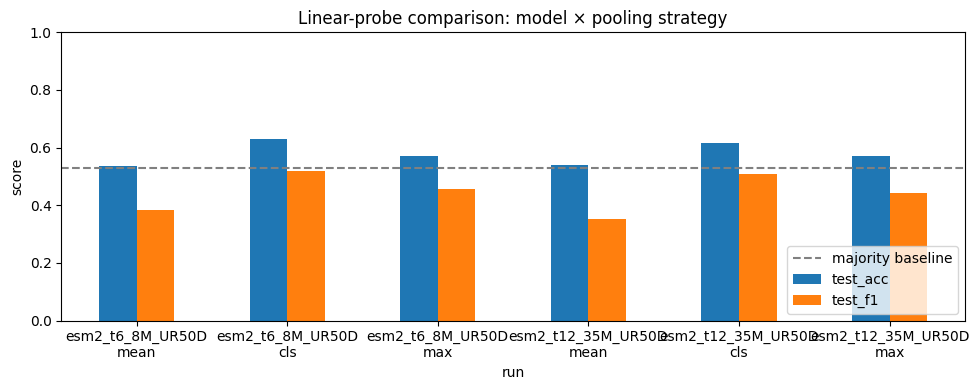

In [8]:
# --- Comparison of all sweep runs -----------------------------------------
# Sorted leaderboard (best F1 first), plus model x pooling pivot tables.
ranked = results_df.sort_values("test_f1", ascending=False).reset_index(drop=True)
print(f"Majority-class baseline accuracy: {baseline:.3f}\n")
print("Leaderboard (best test-F1 first):")
print(ranked.to_string(index=False))

print("\nTest accuracy  (rows = model, cols = pooling):")
print(results_df.pivot(index="model", columns="pooling", values="test_acc").round(3).to_string())
print("\nTest F1        (rows = model, cols = pooling):")
print(results_df.pivot(index="model", columns="pooling", values="test_f1").round(3).to_string())

best = ranked.iloc[0]
print(f"\nBest run: {best['model']} + {best['pooling']} pooling "
      f"-> acc={best['test_acc']:.3f}, f1={best['test_f1']:.3f}")

# Optional bar chart (skipped silently if matplotlib isn't installed).
try:
    import matplotlib.pyplot as plt
    plot_df = results_df.assign(run=results_df["model"] + "\n" + results_df["pooling"]).set_index("run")
    ax = plot_df[["test_acc", "test_f1"]].plot.bar(figsize=(10, 4), rot=0)
    ax.axhline(baseline, ls="--", color="gray", label="majority baseline")
    ax.set_ylabel("score")
    ax.set_ylim(0, 1)
    ax.set_title("Linear-probe comparison: model × pooling strategy")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("\n(matplotlib not installed -- skipping bar chart)")